# Testing the FAO-56 Penman-Monteith Module

This notebook validates the functions implemented in `src/fao56.py` and computes the daily reference evapotranspiration (ET₀).

In [55]:
import math
import numpy as np

## Mount google drives

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import fao56.py

In [ ]:
import sys

project_path = "/content/drive/MyDrive/Colab Notebooks"

if project_path not in sys.path:
    sys.path.insert(0, project_path)

import importlib
import src

importlib.invalidate_caches()
/
import src.weather as weather

import src.crops as crops

import src.irrigation as irrigation

import src.fao56 as fao

import src.advisor as advisor

importlib.reload(irrigation)

importlib.reload(crops)

<module 'src.crops' from '/content/drive/MyDrive/Colab Notebooks/src/crops.py'>

In [42]:
print(fao.__file__)

/content/drive/MyDrive/Colab Notebooks/src/fao56.py


## Display available functions

In [43]:
functions = [
    name for name in dir(fao)
    if callable(getattr(fao, name))
    and not name.startswith("_")
]

print(functions)

['actual_vapor_pressure', 'atmospheric_pressure', 'calculate_daily_et0', 'calculate_daily_et0_from_radiation', 'clear_sky_radiation', 'daylight_hours', 'extraterrestrial_radiation', 'inverse_relative_distance_earth_sun', 'mean_saturation_vapor_pressure', 'net_longwave_radiation', 'net_radiation', 'net_shortwave_radiation', 'psychrometric_constant', 'reference_et0', 'saturation_vapor_pressure', 'slope_vapor_pressure_curve', 'solar_declination', 'solar_radiation', 'sunset_hour_angle', 'wind_speed_2m']


## Define sample weather data

In [44]:
# Weather Data

Tmax = 28.0          # °C
Tmin = 18.0          # °C
Tmean = (Tmax + Tmin) / 2

RH = 70              # %
u2 = 2.0             # m/s

z = 1700             # elevation (m)

latitude = -1.1      # radians (approximately Nairobi)

J = 100              # Day of year

n = 8.5              # actual sunshine hours

# test Atmospheric Pressure

In [45]:
P = fao.atmospheric_pressure(z)

print(f"Atmospheric Pressure = {P:.3f} kPa")

Atmospheric Pressure = 82.754 kPa


In [46]:
# ==========================================================
# FAO-56 Penman-Monteith Test
# ==========================================================

# -----------------------------
# INPUT WEATHER DATA
# -----------------------------
Tmax = 28.0          # °C
Tmin = 18.0          # °C
Tmean = (Tmax + Tmin) / 2

RH = 70              # %
uz = 2.0             # Wind speed measured at z_wind (m/s)
z_wind = 2.0         # Wind measurement height (m)

elevation = 1700     # metres
latitude = math.radians(-1.286)    # radians
J = 100              # Day of year
n = 8.5              # Sunshine hours


# -----------------------------
# VAPOUR PRESSURE
# -----------------------------
es = fao.mean_saturation_vapor_pressure(Tmax, Tmin)
ea = fao.actual_vapor_pressure(es, RH)

print(f"Mean Saturation Vapour Pressure (es): {es:.3f} kPa")
print(f"Actual Vapour Pressure (ea):          {ea:.3f} kPa")


# -----------------------------
# ATMOSPHERIC VARIABLES
# -----------------------------
P = fao.atmospheric_pressure(elevation)
gamma = fao.psychrometric_constant(P)
delta = fao.slope_vapor_pressure_curve(Tmean)

print(f"Atmospheric Pressure:                 {P:.3f} kPa")
print(f"Psychrometric Constant:               {gamma:.5f} kPa/°C")
print(f"Slope Vapour Pressure Curve:          {delta:.5f} kPa/°C")


# -----------------------------
# SOLAR GEOMETRY
# -----------------------------
dr = fao.inverse_relative_distance_earth_sun(J)
solar_dec = fao.solar_declination(J)
ws = fao.sunset_hour_angle(latitude, solar_dec)

print(f"Inverse Relative Earth-Sun Distance:  {dr:.3f}")
print(f"Solar Declination:                    {solar_dec:.3f} rad")
print(f"Sunset Hour Angle:                    {ws:.3f} rad")


# -----------------------------
# RADIATION
# -----------------------------
Ra = fao.extraterrestrial_radiation(latitude, J)
N = fao.daylight_hours(ws)

Rs = fao.solar_radiation(n, N, Ra)
Rso = fao.clear_sky_radiation(elevation, Ra)

Rns = fao.net_shortwave_radiation(Rs)
Rnl = fao.net_longwave_radiation(
    Tmax + 273.16,
    Tmin + 273.16,
    ea,
    Rs,
    Rso
)

Rn = fao.net_radiation(Rns, Rnl)

print(f"Extraterrestrial Radiation (Ra):      {Ra:.3f} MJ/m²/day")
print(f"Maximum Daylight Hours (N):           {N:.3f} h")
print(f"Solar Radiation (Rs):                 {Rs:.3f} MJ/m²/day")
print(f"Clear Sky Radiation (Rso):            {Rso:.3f} MJ/m²/day")
print(f"Net Shortwave Radiation (Rns):        {Rns:.3f} MJ/m²/day")
print(f"Net Longwave Radiation (Rnl):         {Rnl:.3f} MJ/m²/day")
print(f"Net Radiation (Rn):                   {Rn:.3f} MJ/m²/day")


# -----------------------------
# WIND SPEED
# -----------------------------
u2 = fao.wind_speed_2m(uz, z_wind)

print(f"Wind Speed at 2 m:                    {u2:.3f} m/s")


# -----------------------------
# SOIL HEAT FLUX
# -----------------------------
G = 0.0


# -----------------------------
# REFERENCE ET0
# -----------------------------
ET0 = fao.reference_et0(
    slope_vapor_pressure_curve=delta,
    net_rad=Rn,
    soil_heat_flux=G,
    psychrometric_constant=gamma,
    mean_temp=Tmean,
    wind_speed=u2,
    saturation_vapor_pressure=es,
    actual_vapor_pressure=ea,
)

print("\n========================================")
print(f"Reference ET₀ = {ET0:.3f} mm/day")
print("========================================")

Mean Saturation Vapour Pressure (es): 2.922 kPa
Actual Vapour Pressure (ea):          2.045 kPa
Atmospheric Pressure:                 82.754 kPa
Psychrometric Constant:               0.05503 kPa/°C
Slope Vapour Pressure Curve:          0.16992 kPa/°C
Inverse Relative Earth-Sun Distance:  0.995
Solar Declination:                    0.133 rad
Sunset Hour Angle:                    1.568 rad
Extraterrestrial Radiation (Ra):      36.885 MJ/m²/day
Maximum Daylight Hours (N):           11.977 h
Solar Radiation (Rs):                 35.208 MJ/m²/day
Clear Sky Radiation (Rso):            28.918 MJ/m²/day
Net Shortwave Radiation (Rns):        27.110 MJ/m²/day
Net Longwave Radiation (Rnl):         6.832 MJ/m²/day
Net Radiation (Rn):                   20.278 MJ/m²/day
Wind Speed at 2 m:                    2.000 m/s

Reference ET₀ = 6.476 mm/day


In [47]:
import importlib
import src.fao56 as fao

importlib.reload(fao)

82.75438254773033
0.05503166439424067
2.338281270927446
2.921959783327874


<module 'src.fao56' from '/content/drive/MyDrive/Colab Notebooks/src/fao56.py'>

In [48]:
et0 = fao.calculate_daily_et0(
    Tmax=28,
    Tmin=18,
    RH=70,
    wind_speed=2,
    wind_height=2,
    elevation=1700,
    latitude_deg=-1.286,
    day_of_year=100,
    sunshine_hours=8.5,
)

print(f"ET₀ = {et0:.3f} mm/day")

ET₀ = 6.476 mm/day


In [49]:
!ls "/content/drive/MyDrive/Colab Notebooks/src"

advisor.py	  data	      __init__.py	  __pycache__
crop_calendar.py  dataset.py  irrigation.py	  soil
crops.py	  fao56.py    kiambu_weather.csv  weather.py


## test weather module

In [50]:
weather_data = weather.sample_weather()

weather_data

{'Tmax': 28.0,
 'Tmin': 18.0,
 'RH': 70,
 'wind_speed': 2.0,
 'wind_height': 2.0,
 'sunshine_hours': 8.5,
 'latitude_deg': -1.246,
 'longitude_deg': 36.662,
 'elevation': 1800,
 'day_of_year': 100}

In [51]:
et0 = fao.calculate_daily_et0(
    Tmax=weather_data["Tmax"],
    Tmin=weather_data["Tmin"],
    RH=weather_data["RH"],
    wind_speed=weather_data["wind_speed"],
    wind_height=weather_data["wind_height"],
    elevation=weather_data["elevation"],
    latitude_deg=weather_data["latitude_deg"],
    day_of_year=weather_data["day_of_year"],
    sunshine_hours=weather_data["sunshine_hours"]
)

## testing kc

In [52]:
kc = crops.get_crop_coefficient(
    crop="Tomato",
    stage="mid"
)

print(kc)

1.15


## calculate crop evapotranspiration (ETc)

In [53]:
weather_data = weather.sample_weather()

et0 = fao.calculate_daily_et0(
    Tmax=weather_data["Tmax"],
    Tmin=weather_data["Tmin"],
    RH=weather_data["RH"],
    wind_speed=weather_data["wind_speed"],
    wind_height=weather_data["wind_height"],
    elevation=weather_data["elevation"],
    latitude_deg=weather_data["latitude_deg"],
    day_of_year=weather_data["day_of_year"],
    sunshine_hours=weather_data["sunshine_hours"]
)

kc = crops.get_crop_coefficient(
    crop="Tomato",
    stage="mid"
)

etc = et0 * kc

print(f"ET₀ = {et0:.3f} mm/day")
print(f"Kc  = {kc:.2f}")
print(f"ETc = {etc:.3f} mm/day")

ET₀ = 6.498 mm/day
Kc  = 1.15
ETc = 7.472 mm/day


## testing full pipeline

In [56]:
# Weather
weather_data = weather.sample_weather()

# Reference ET
et0 = fao.calculate_daily_et0(
    Tmax=weather_data["Tmax"],
    Tmin=weather_data["Tmin"],
    RH=weather_data["RH"],
    wind_speed=weather_data["wind_speed"],
    wind_height=weather_data["wind_height"],
    elevation=weather_data["elevation"],
    latitude_deg=weather_data["latitude_deg"],
    day_of_year=weather_data["day_of_year"],
    sunshine_hours=weather_data["sunshine_hours"]
)

# Crop coefficient
kc = crops.get_crop_coefficient(
    crop="Tomato",
    stage="mid"
)

# Crop water use
etc = irrigation.crop_evapotranspiration(et0, kc)

# Assume no rainfall today
nir = irrigation.net_irrigation_requirement(
    etc,
    effective_rainfall=0
)

# Assume 85% irrigation efficiency
gir = irrigation.gross_irrigation_requirement(
    nir,
    efficiency=0.85
)

print("=" * 50)
print("AI IRRIGATION ADVISOR")
print("=" * 50)
print(f"Reference ET₀          : {et0:.2f} mm/day")
print(f"Crop Coefficient (Kc)  : {kc:.2f}")
print(f"Crop ET (ETc)          : {etc:.2f} mm/day")
print(f"Net Irrigation (NIR)   : {nir:.2f} mm/day")
print(f"Gross Irrigation (GIR) : {gir:.2f} mm/day")

AttributeError: module 'src.irrigation' has no attribute 'crop_evapotranspiration'

In [57]:
dir(irrigation)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'assign_tomato_calendar',
 'calculate_available_water',
 'calculate_daily_irrigation',
 'calculate_daily_irrigation_for_crop',
 'calculate_effective_rainfall',
 'calculate_etc',
 'calculate_gross_irrigation',
 'calculate_irrigation_amount',
 'calculate_net_irrigation',
 'calculate_raw',
 'calculate_root_zone_depletion',
 'calculate_taw',
 'fao_should_irrigate',
 'get_kc',
 'get_muguga_water_parameters',
 'should_irrigate',
 'update_root_zone_depletion',
 'update_soil_water']

## test advisor

In [59]:
# Weather
weather_data = weather.sample_weather()

# ET0
et0 = fao.calculate_daily_et0(
    Tmax=weather_data["Tmax"],
    Tmin=weather_data["Tmin"],
    RH=weather_data["RH"],
    wind_speed=weather_data["wind_speed"],
    wind_height=weather_data["wind_height"],
    elevation=weather_data["elevation"],
    latitude_deg=weather_data["latitude_deg"],
    day_of_year=weather_data["day_of_year"],
    sunshine_hours=weather_data["sunshine_hours"]
)

# Crop coefficient
kc = crops.get_crop_coefficient(
    crop="Tomato",
    stage="mid"
)

# Crop water requirement
etc = irrigation.crop_evapotranspiration(et0, kc)

nir = irrigation.net_irrigation_requirement(
    etc,
    effective_rainfall=0
)

gir = irrigation.gross_irrigation_requirement(
    nir,
    efficiency=0.85
)

# AI recommendation
recommendation = advisor.irrigation_advice(
    gir=gir,
    rainfall=0
)

print("=" * 60)
print("AI IRRIGATION ADVISOR")
print("=" * 60)

print(f"Reference ET₀ : {et0:.2f} mm/day")
print(f"Crop ET       : {etc:.2f} mm/day")
print(f"Gross Irrigation Requirement : {gir:.2f} mm/day")

print("\nRecommendation")
print("-------------------------")
print(recommendation["message"])

AttributeError: module 'src.irrigation' has no attribute 'crop_evapotranspiration'

In [60]:
from src.soil.config import (
    SOILGRIDS_URL,
    SOIL_PROPERTIES,
    CACHE
)

print("SoilGrids URL:")
print(SOILGRIDS_URL)

print("\nSoil properties:")
print(SOIL_PROPERTIES)

print("\nCache directory:")
print(CACHE)

SoilGrids URL:
https://rest.isric.org/soilgrids/v2.0/properties/query

Soil properties:
['bdod', 'cec', 'clay', 'nitrogen', 'phh2o', 'sand', 'silt', 'soc']

Cache directory:
/content/drive/MyDrive/Colab Notebooks/src/data/cache


In [61]:
from src.soil.soils import SoilDownloader

soil_downloader = SoilDownloader()

print("SoilDownloader created successfully.")

SoilDownloader created successfully.


In [63]:
import requests
import json

url = "https://rest.isric.org/soilgrids/v2.0/properties/query"

params = {
    "lon": 36.662,
    "lat": -1.246,
    "property": [
        "bdod",
        "cec",
        "clay",
        "nitrogen",
        "phh2o",
        "sand",
        "silt",
        "soc"
    ],
    "depth": "0-5cm",
    "value": "mean"
}

response = requests.get(
    url,
    params=params,
    timeout=30
)

print("Status code:", response.status_code)
print("\nResponse URL:")
print(response.url)

print("\nResponse:")
print(json.dumps(response.json(), indent=2)[:10000])

Status code: 200

Response URL:
https://rest.isric.org/soilgrids/v2.0/properties/query?lon=36.662&lat=-1.246&property=bdod&property=cec&property=clay&property=nitrogen&property=phh2o&property=sand&property=silt&property=soc&depth=0-5cm&value=mean

Response:
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      36.662,
      -1.246
    ]
  },
  "properties": {
    "layers": [
      {
        "name": "bdod",
        "unit_measure": {
          "d_factor": 100,
          "mapped_units": "cg/cm\u00b3",
          "target_units": "kg/dm\u00b3",
          "uncertainty_unit": ""
        },
        "depths": [
          {
            "range": {
              "top_depth": 0,
              "bottom_depth": 5,
              "unit_depth": "cm"
            },
            "label": "0-5cm",
            "values": {
              "mean": null
            }
          }
        ]
      },
      {
        "name": "cec",
        "unit_measure": {
          "d_factor": 10,
   

In [64]:
## Test whether the problem is the depth

import requests
import json

url = "https://rest.isric.org/soilgrids/v2.0/properties/query"

params = {
    "lon": 36.662,
    "lat": -1.246,
    "property": ["clay", "sand", "silt"],
    "depth": "5-15cm",
    "value": "mean"
}

response = requests.get(
    url,
    params=params,
    timeout=30
)

print("Status:", response.status_code)

data = response.json()

for layer in data["properties"]["layers"]:
    print(
        layer["name"],
        "→",
        layer["depths"][0]["values"]["mean"]
    )

Status: 200
clay → None
sand → None
silt → None


In [65]:
import pandas as pd

soil_path = "G:\My Drive\Colab Notebooks\src\soil\muguga_soil.csv"

soil_df = pd.read_csv(soil_path)

print(soil_df)

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_524/2350728758.py:3: SyntaxWarning: invalid escape sequence '\M'
  soil_path = "G:\My Drive\Colab Notebooks\src\soil\muguga_soil.csv"


FileNotFoundError: [Errno 2] No such file or directory: 'G:\\My Drive\\Colab Notebooks\\src\\soil\\muguga_soil.csv'

In [ ]:
import pandas as pd

soil_path = "src/soil/dummy_muguga_soil.csv"

soil_df = pd.read_csv(soil_path)

print(soil_df)

In [67]:
import os

soil_folder = "/content/drive/MyDrive/Colab Notebooks/src/soil"

print(os.listdir(soil_folder))

['utils.py', 'build_soil_dataset.py', 'data', '__pycache__', 'muguga_soil.csv', '__init__.py', 'config.py', 'soils.py', 'dummy_muguga_soil.csv']


In [66]:
import pandas as pd

dummy_soil = pd.DataFrame([{
    "location": "Muguga",
    "latitude": -1.246,
    "longitude": 36.662,
    "sand_percent": 40,
    "silt_percent": 40,
    "clay_percent": 20,
    "bulk_density_g_cm3": 1.35,
    "ph": 6.2,
    "organic_carbon_percent": 1.8,
    "cec_cmol_kg": 18,
    "nitrogen_g_kg": 1.2,
    "field_capacity": 0.30,
    "wilting_point": 0.15,
    "available_water": 0.15
}])

soil_path = "/content/drive/MyDrive/Colab Notebooks/src/soil/dummy_muguga_soil.csv"

dummy_soil.to_csv(soil_path, index=False)

print("Saved successfully:")
print(soil_path)

Saved successfully:
/content/drive/MyDrive/Colab Notebooks/src/soil/dummy_muguga_soil.csv


In [68]:
import pandas as pd

soil_path = "G:\My Drive\Colab Notebooks\src\soil\dummy_muguga_soil.csv"

soil_df = pd.read_csv(soil_path)

print(soil_df)

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_524/4231710054.py:3: SyntaxWarning: invalid escape sequence '\M'
  soil_path = "G:\My Drive\Colab Notebooks\src\soil\dummy_muguga_soil.csv"


FileNotFoundError: [Errno 2] No such file or directory: 'G:\\My Drive\\Colab Notebooks\\src\\soil\\dummy_muguga_soil.csv'

In [ ]:
soil_df = pd.read_csv(soil_path)

print(soil_df)


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [69]:
import os

project_path = "/content/drive/MyDrive/Colab Notebooks"

print(os.path.exists(project_path))
print(os.listdir(project_path))


True
['Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled2 (1).ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', 'Untitled7.ipynb', 'Untitled8.ipynb', 'Untitled9.ipynb', 'Untitled (2)', 'Untitled (1)', 'Untitled11.ipynb', 'Untitled12.ipynb', 'Untitled10.ipynb', 'Untitled13.ipynb', 'Untitled14.ipynb', 'Untitled15.ipynb', 'Untitled16.ipynb', 'Untitled17.ipynb', 'N_Proj_weather dataset.ipynb', 'Untitled19.ipynb', 'Untitled18.ipynb', 'Untitled', 'Untitled20.ipynb', 'Untitled21.ipynb', 'Untitled22.ipynb', '04_feature_engineering.ipynb', 'src', '03_Test_FAO56.ipynb']


In [70]:
soil_folder = "/content/drive/MyDrive/Colab Notebooks/src/soil"

print("Folder exists:", os.path.exists(soil_folder))

print("\nContents:")
print(os.listdir(soil_folder))

Folder exists: True

Contents:
['utils.py', 'build_soil_dataset.py', 'data', '__pycache__', 'muguga_soil.csv', '__init__.py', 'config.py', 'soils.py', 'dummy_muguga_soil.csv']


In [71]:
import pandas as pd
import os

soil_folder = "/content/drive/MyDrive/Colab Notebooks/src/soil"

dummy_soil = pd.DataFrame([{
    "location": "Muguga",
    "latitude": -1.246,
    "longitude": 36.662,
    "sand_percent": 40,
    "silt_percent": 40,
    "clay_percent": 20,
    "bulk_density_g_cm3": 1.35,
    "ph": 6.2,
    "organic_carbon_percent": 1.8,
    "cec_cmol_kg": 18,
    "nitrogen_g_kg": 1.2,
    "field_capacity": 0.30,
    "wilting_point": 0.15,
    "available_water": 0.15
}])

soil_path = os.path.join(
    soil_folder,
    "dummy_muguga_soil.csv"
)

dummy_soil.to_csv(soil_path, index=False)

print("Created successfully:")
print(soil_path)

Created successfully:
/content/drive/MyDrive/Colab Notebooks/src/soil/dummy_muguga_soil.csv


In [72]:
soil_df = pd.read_csv(soil_path)

print(soil_df)

  location  latitude  longitude  sand_percent  silt_percent  clay_percent  \
0   Muguga    -1.246     36.662            40            40            20   

   bulk_density_g_cm3   ph  organic_carbon_percent  cec_cmol_kg  \
0                1.35  6.2                     1.8           18   

   nitrogen_g_kg  field_capacity  wilting_point  available_water  
0            1.2             0.3           0.15             0.15  


In [73]:
from src.soil.soils import load_muguga_soil

soil_df = load_muguga_soil()

print(soil_df)

  location  latitude  longitude  sand_percent  silt_percent  clay_percent  \
0   Muguga    -1.246     36.662            40            40            20   

   bulk_density_g_cm3   ph  organic_carbon_percent  cec_cmol_kg  \
0                1.35  6.2                     1.8           18   

   nitrogen_g_kg  field_capacity  wilting_point  available_water  
0            1.2             0.3           0.15             0.15  


In [74]:
import sys

project_path = "/content/drive/MyDrive/Colab Notebooks"

if project_path not in sys.path:
    sys.path.insert(0, project_path)

In [75]:
import importlib
import src.soil.soils as soils

importlib.reload(soils)

<module 'src.soil.soils' from '/content/drive/MyDrive/Colab Notebooks/src/soil/soils.py'>

In [76]:
soil_df = soils.load_muguga_soil()

print(soil_df)

  location  latitude  longitude  sand_percent  silt_percent  clay_percent  \
0   Muguga    -1.246     36.662            40            40            20   

   bulk_density_g_cm3   ph  organic_carbon_percent  cec_cmol_kg  \
0                1.35  6.2                     1.8           18   

   nitrogen_g_kg  field_capacity  wilting_point  available_water  
0            1.2             0.3           0.15             0.15  


In [77]:
import importlib
import src.irrigation as irrigation

importlib.reload(irrigation)

print(irrigation.__file__)
print(dir(irrigation))

/content/drive/MyDrive/Colab Notebooks/src/irrigation.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'assign_tomato_calendar', 'calculate_available_water', 'calculate_daily_irrigation', 'calculate_daily_irrigation_for_crop', 'calculate_effective_rainfall', 'calculate_etc', 'calculate_gross_irrigation', 'calculate_irrigation_amount', 'calculate_net_irrigation', 'calculate_raw', 'calculate_root_zone_depletion', 'calculate_taw', 'fao_should_irrigate', 'get_kc', 'get_muguga_water_parameters', 'should_irrigate', 'update_root_zone_depletion', 'update_soil_water']


In [78]:
from src.irrigation import calculate_etc


# Example values
et0 = 6.0
kc = 0.90


etc = calculate_etc(et0, kc)


print("ET0:", et0, "mm/day")
print("Kc:", kc)
print("ETc:", round(etc, 3), "mm/day")

ET0: 6.0 mm/day
Kc: 0.9
ETc: 5.4 mm/day


In [79]:
available_water = irrigation.calculate_available_water(
    field_capacity=0.30,
    wilting_point=0.15,
    root_depth=0.60
)

print(
    "Available root-zone water:",
    round(available_water, 2),
    "mm"
)

Available root-zone water: 90.0 mm


In [80]:
soil_water = irrigation.update_soil_water(
    previous_soil_water=60,
    rainfall=5,
    irrigation=0,
    etc=6,
    available_water=90
)

print("Updated soil water:", soil_water, "mm")

Updated soil water: 59 mm


In [81]:
import importlib
import src.irrigation as irrigation

importlib.reload(irrigation)

decision = irrigation.should_irrigate(
    soil_water=59,
    available_water=90
)

print("Irrigate:", decision)

Irrigate: False


In [ ]:
decision = irrigation.should_irrigate(
    soil_water=40,
    available_water=90
)

print("Irrigate:", decision)

In [82]:
import importlib
import src.irrigation as irrigation

importlib.reload(irrigation)

<module 'src.irrigation' from '/content/drive/MyDrive/Colab Notebooks/src/irrigation.py'>

In [84]:
amount = irrigation.calculate_irrigation_amount(
    soil_water=40,
    available_water=90
)

print("Irrigation amount:", round(amount, 2), "mm")

Irrigation amount: 41.0 mm


In [83]:
soil_water = 40
available_water = 90

decision = irrigation.should_irrigate(
    soil_water=soil_water,
    available_water=available_water
)

if decision:
    amount = irrigation.calculate_irrigation_amount(
        soil_water=soil_water,
        available_water=available_water
    )
else:
    amount = 0

print("Irrigate:", decision)
print("Amount:", round(amount, 2), "mm")

Irrigate: True
Amount: 41.0 mm


In [85]:
import importlib
import src.irrigation as irrigation

importlib.reload(irrigation)

<module 'src.irrigation' from '/content/drive/MyDrive/Colab Notebooks/src/irrigation.py'>

In [86]:
gross_irrigation = irrigation.calculate_gross_irrigation(
    net_irrigation=36,
    irrigation_efficiency=0.80
)

print(
    "Gross irrigation requirement:",
    round(gross_irrigation, 2),
    "mm"
)

Gross irrigation requirement: 45.0 mm


## weather_df

In [87]:
weather_df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/src/kiambu_weather.csv"
)

weather_df["Date"] = pd.to_datetime(weather_df["Date"])

In [88]:
print(weather_df.columns.tolist())

['Date', 'Temperature', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation']


In [89]:
from pathlib import Path

for p in Path("/content/drive/MyDrive/Colab Notebooks").rglob("*.csv"):
    print(p)

/content/drive/MyDrive/Colab Notebooks/src/kiambu_weather.csv
/content/drive/MyDrive/Colab Notebooks/src/soil/muguga_soil.csv
/content/drive/MyDrive/Colab Notebooks/src/soil/dummy_muguga_soil.csv
/content/drive/MyDrive/Colab Notebooks/src/.venv/Lib/site-packages/tornado/test/csv_translations/fr_FR.csv


In [90]:
import pandas as pd

weather_df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/src/kiambu_weather.csv"
)

weather_df["Date"] = pd.to_datetime(weather_df["Date"])

print(weather_df.shape)
print(weather_df.head())

(3653, 8)
        Date  Temperature  Max_Temperature  Min_Temperature  \
0 2016-01-01        19.94            26.62            14.85   
1 2016-01-02        18.89            26.15            13.02   
2 2016-01-03        18.77            25.95            13.02   
3 2016-01-04        18.80            24.16            15.21   
4 2016-01-05        18.58            24.22            15.05   

   Relative_Humidity  Rainfall  Wind_Speed  Solar_Radiation  
0              72.57      0.01        2.70            26.93  
1              73.27      0.49        2.97            25.65  
2              78.50      5.70        3.29            24.74  
3              83.54     11.28        4.17            16.70  
4              82.98      7.03        4.02            24.17  


In [91]:
print(weather_df.columns.tolist())

['Date', 'Temperature', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation']


In [92]:
taw = irrigation.calculate_taw(
    field_capacity=0.30,
    wilting_point=0.15,
    root_depth=0.60
)

raw = irrigation.calculate_raw(
    taw=taw,
    depletion_fraction=0.40
)

print("TAW:", round(taw, 2), "mm")
print("RAW:", round(raw, 2), "mm")

TAW: 90.0 mm
RAW: 36.0 mm


In [93]:
weather_df["Tmean"] = (
    weather_df["Max_Temperature"]
    + weather_df["Min_Temperature"]
) / 2

print(
    weather_df[
        ["Date", "Max_Temperature", "Min_Temperature", "Tmean"]
    ].head()
)

        Date  Max_Temperature  Min_Temperature   Tmean
0 2016-01-01            26.62            14.85  20.735
1 2016-01-02            26.15            13.02  19.585
2 2016-01-03            25.95            13.02  19.485
3 2016-01-04            24.16            15.21  19.685
4 2016-01-05            24.22            15.05  19.635


In [94]:
from src import irrigation

weather_df["Date"] = pd.to_datetime(weather_df["Date"])

weather_df["ET0"] = weather_df.apply(
    lambda row: irrigation.calculate_daily_et0(
        Tmax=row["Max_Temperature"],
        Tmin=row["Min_Temperature"],
        RH=row["Relative_Humidity"],
        wind_speed=row["Wind_Speed"],
        wind_height=2.0,
        elevation=1700,
        latitude_deg=-1.25,
        day_of_year=row["Date"].dayofyear,
        sunshine_hours=10.0
    ),
    axis=1
)

print(
    weather_df[
        ["Date", "Tmean", "Solar_Radiation", "ET0"]
    ].head(10)
)

AttributeError: module 'src.irrigation' has no attribute 'calculate_daily_et0'

In [95]:
from src import fao56

In [102]:
print(hasattr(irrigation, "calculate_daily_et0"))

False


In [101]:
print(
    weather_df[
        ["Date", "Tmean"]
    ].head(10)
)

        Date   Tmean
0 2016-01-01  20.735
1 2016-01-02  19.585
2 2016-01-03  19.485
3 2016-01-04  19.685
4 2016-01-05  19.635
5 2016-01-06  19.765
6 2016-01-07  19.730
7 2016-01-08  19.450
8 2016-01-09  19.440
9 2016-01-10  20.110


In [103]:
import inspect

print(inspect.signature(fao56.calculate_daily_et0_from_radiation))

(Tmax, Tmin, RH, wind_speed, wind_height, elevation, latitude_deg, day_of_year, Rs)


In [104]:
print(inspect.signature(fao56.calculate_daily_et0))

(Tmax, Tmin, RH, wind_speed, wind_height, elevation, latitude_deg, day_of_year, sunshine_hours)


In [105]:
from src import fao56

weather_df["ET0"] = weather_df.apply(
    lambda row: fao56.calculate_daily_et0(
        Tmax=row["Max_Temperature"],
        Tmin=row["Min_Temperature"],
        RH=row["Relative_Humidity"],
        wind_speed=row["Wind_Speed"],
        wind_height=2.0,
        elevation=1700,
        latitude_deg=-1.25,
        day_of_year=row["Date"].dayofyear,
        sunshine_hours=10.0
    ),
    axis=1
)

print(
    weather_df[
        ["Date", "Tmean", "Solar_Radiation", "ET0"]
    ].head(10)
)

        Date   Tmean  Solar_Radiation       ET0
0 2016-01-01  20.735            26.93  5.518759
1 2016-01-02  19.585            25.65  5.350460
2 2016-01-03  19.485            24.74  5.129434
3 2016-01-04  19.685            16.70  4.813847
4 2016-01-05  19.635            24.17  4.852370
5 2016-01-06  19.765            24.46  5.098837
6 2016-01-07  19.730            24.49  5.158516
7 2016-01-08  19.450            25.45  5.276671
8 2016-01-09  19.440            23.15  5.292522
9 2016-01-10  20.110            15.13  5.361262


In [106]:
weather_df["ET0"] = weather_df.apply(
    lambda row: fao56.calculate_daily_et0_from_radiation(
        Tmax=row["Max_Temperature"],
        Tmin=row["Min_Temperature"],
        RH=row["Relative_Humidity"],
        wind_speed=row["Wind_Speed"],
        wind_height=2.0,
        elevation=1700,
        latitude_deg=-1.25,
        day_of_year=row["Date"].dayofyear,
        Rs=row["Solar_Radiation"]
    ),
    axis=1
)

In [107]:
import inspect

print(inspect.signature(fao56.calculate_daily_et0_from_radiation))

(Tmax, Tmin, RH, wind_speed, wind_height, elevation, latitude_deg, day_of_year, Rs)


In [108]:
print(
    weather_df[
        ["Date", "Solar_Radiation", "ET0"]
    ].head(10)
)

        Date  Solar_Radiation       ET0
0 2016-01-01            26.93  5.025287
1 2016-01-02            25.65  4.731757
2 2016-01-03            24.74  4.406865
3 2016-01-04            16.70  3.230358
4 2016-01-05            24.17  4.088730
5 2016-01-06            24.46  4.330793
6 2016-01-07            24.49  4.380002
7 2016-01-08            25.45  4.610284
8 2016-01-09            23.15  4.348790
9 2016-01-10            15.13  3.360136


In [109]:
print("ET0 missing:", weather_df["ET0"].isna().sum())
print("ET0 minimum:", weather_df["ET0"].min())
print("ET0 maximum:", weather_df["ET0"].max())
print("ET0 mean:", weather_df["ET0"].mean())

ET0 missing: 0
ET0 minimum: 1.568068668635932
ET0 maximum: 7.1972577328142116
ET0 mean: 4.300831804690355


In [110]:
print(
    weather_df[
        ["Date", "Tmean", "Solar_Radiation", "ET0"]
    ].tail()
)

           Date   Tmean  Solar_Radiation       ET0
3648 2025-12-27  21.115            17.75  3.629115
3649 2025-12-28  18.245             6.13  1.568069
3650 2025-12-29  19.855            15.30  3.276221
3651 2025-12-30  19.165            14.97  2.872726
3652 2025-12-31  20.200            23.64  4.445744


In [111]:
print(weather_df.columns.tolist())

['Date', 'Temperature', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation', 'Tmean', 'ET0']


In [112]:
print("ET0 missing:", weather_df["ET0"].isna().sum())
print("ET0 minimum:", weather_df["ET0"].min())
print("ET0 maximum:", weather_df["ET0"].max())
print("ET0 mean:", weather_df["ET0"].mean())

ET0 missing: 0
ET0 minimum: 1.568068668635932
ET0 maximum: 7.1972577328142116
ET0 mean: 4.300831804690355


In [113]:
weather_df["ET0"] = weather_df.apply(
    lambda row: fao56.calculate_daily_et0(
        Tmax=row["Max_Temperature"],
        Tmin=row["Min_Temperature"],
        RH=row["Relative_Humidity"],
        wind_speed=row["Wind_Speed"],
        wind_height=2.0,
        elevation=1700,
        latitude_deg=-1.25,
        day_of_year=row["Date"].dayofyear,
        sunshine_hours=10.0
    ),
    axis=1
)

In [114]:
weather_df["planting_date"] = pd.to_datetime(
    weather_df["Date"].dt.year.astype(str) + "-01-01"
)

weather_df["crop_age"] = (
    weather_df["Date"] - weather_df["planting_date"]
).dt.days

print(
    weather_df[
        ["Date", "planting_date", "crop_age"]
    ].head(35)
)

         Date planting_date  crop_age
0  2016-01-01    2016-01-01         0
1  2016-01-02    2016-01-01         1
2  2016-01-03    2016-01-01         2
3  2016-01-04    2016-01-01         3
4  2016-01-05    2016-01-01         4
5  2016-01-06    2016-01-01         5
6  2016-01-07    2016-01-01         6
7  2016-01-08    2016-01-01         7
8  2016-01-09    2016-01-01         8
9  2016-01-10    2016-01-01         9
10 2016-01-11    2016-01-01        10
11 2016-01-12    2016-01-01        11
12 2016-01-13    2016-01-01        12
13 2016-01-14    2016-01-01        13
14 2016-01-15    2016-01-01        14
15 2016-01-16    2016-01-01        15
16 2016-01-17    2016-01-01        16
17 2016-01-18    2016-01-01        17
18 2016-01-19    2016-01-01        18
19 2016-01-20    2016-01-01        19
20 2016-01-21    2016-01-01        20
21 2016-01-22    2016-01-01        21
22 2016-01-23    2016-01-01        22
23 2016-01-24    2016-01-01        23
24 2016-01-25    2016-01-01        24
25 2016-01-2

In [115]:
def get_growth_stage(crop_age):

    if crop_age <= 30:
        return "Initial"

    elif crop_age <= 60:
        return "Development"

    elif crop_age <= 90:
        return "Mid-season"

    elif crop_age <= 120:
        return "Late-season"

    else:
        return "No crop"


def get_kc(crop_age):

    if crop_age <= 30:
        return 0.60

    elif crop_age <= 60:
        return 0.90

    elif crop_age <= 90:
        return 1.15

    elif crop_age <= 120:
        return 0.80

    else:
        return 0.00

In [116]:
weather_df["growth_stage"] = weather_df["crop_age"].apply(
    get_growth_stage
)

weather_df["Kc"] = weather_df["crop_age"].apply(
    get_kc
)

In [117]:
print(weather_df["Kc"].value_counts())

Kc
0.00    2443
0.60     310
0.90     300
1.15     300
0.80     300
Name: count, dtype: int64


In [118]:
weather_df["ETc"] = (
    weather_df["ET0"] * weather_df["Kc"]
)

In [119]:
print(
    weather_df[
        ["Date", "ET0", "Kc", "ETc"]
    ].head(10)
)

        Date       ET0   Kc       ETc
0 2016-01-01  5.518759  0.6  3.311255
1 2016-01-02  5.350460  0.6  3.210276
2 2016-01-03  5.129434  0.6  3.077660
3 2016-01-04  4.813847  0.6  2.888308
4 2016-01-05  4.852370  0.6  2.911422
5 2016-01-06  5.098837  0.6  3.059302
6 2016-01-07  5.158516  0.6  3.095109
7 2016-01-08  5.276671  0.6  3.166003
8 2016-01-09  5.292522  0.6  3.175513
9 2016-01-10  5.361262  0.6  3.216757


In [120]:
weather_df["effective_rainfall"] = (
    weather_df["Rainfall"] * 0.80
)

In [121]:
print(
    weather_df[
        ["Date", "Rainfall", "effective_rainfall", "ETc"]
    ].head(20)
)

         Date  Rainfall  effective_rainfall       ETc
0  2016-01-01      0.01               0.008  3.311255
1  2016-01-02      0.49               0.392  3.210276
2  2016-01-03      5.70               4.560  3.077660
3  2016-01-04     11.28               9.024  2.888308
4  2016-01-05      7.03               5.624  2.911422
5  2016-01-06      0.79               0.632  3.059302
6  2016-01-07      0.10               0.080  3.095109
7  2016-01-08      0.02               0.016  3.166003
8  2016-01-09      0.01               0.008  3.175513
9  2016-01-10      0.04               0.032  3.216757
10 2016-01-11      1.63               1.304  3.041439
11 2016-01-12      2.43               1.944  3.048568
12 2016-01-13      0.24               0.192  3.169359
13 2016-01-14      0.79               0.632  3.214547
14 2016-01-15      1.92               1.536  3.226005
15 2016-01-16      2.71               2.168  3.023425
16 2016-01-17      6.18               4.944  3.124435
17 2016-01-18     13.73     

In [122]:
depletion = 0.0

depletions = []

for _, row in weather_df.iterrows():

    depletion = (
        depletion
        + row["ETc"]
        - row["effective_rainfall"]
    )

    depletion = max(0.0, min(depletion, 90.0))

    depletions.append(depletion)

weather_df["depletion"] = depletions

#TAW

In [123]:
weather_df["field_capacity"] = 0.30
weather_df["wilting_point"] = 0.15
weather_df["root_depth"] = 0.60

weather_df["TAW"] = (
    (weather_df["field_capacity"] - weather_df["wilting_point"])
    * weather_df["root_depth"]
    * 1000
)

weather_df["RAW"] = weather_df["TAW"] * 0.40

In [124]:
print(
    "Minimum depletion:",
    weather_df["depletion"].min()
)

print(
    "Maximum depletion:",
    weather_df["depletion"].max()
)

print(
    weather_df[
        [
            "Date",
            "ETc",
            "Rainfall",
            "effective_rainfall",
            "TAW",
            "depletion"
        ]
    ].head(20)
)

Minimum depletion: 0.0
Maximum depletion: 90.0
         Date       ETc  Rainfall  effective_rainfall   TAW  depletion
0  2016-01-01  3.311255      0.01               0.008  90.0   3.303255
1  2016-01-02  3.210276      0.49               0.392  90.0   6.121531
2  2016-01-03  3.077660      5.70               4.560  90.0   4.639192
3  2016-01-04  2.888308     11.28               9.024  90.0   0.000000
4  2016-01-05  2.911422      7.03               5.624  90.0   0.000000
5  2016-01-06  3.059302      0.79               0.632  90.0   2.427302
6  2016-01-07  3.095109      0.10               0.080  90.0   5.442412
7  2016-01-08  3.166003      0.02               0.016  90.0   8.592415
8  2016-01-09  3.175513      0.01               0.008  90.0  11.759927
9  2016-01-10  3.216757      0.04               0.032  90.0  14.944685
10 2016-01-11  3.041439      1.63               1.304  90.0  16.682124
11 2016-01-12  3.048568      2.43               1.944  90.0  17.786691
12 2016-01-13  3.169359      0

In [125]:
depletion = 0.0
depletions = []

for _, row in weather_df.iterrows():

    depletion = (
        depletion
        + row["ETc"]
        - row["effective_rainfall"]
    )

    depletion = max(
        0.0,
        min(depletion, row["TAW"])
    )

    depletions.append(depletion)

weather_df["depletion"] = depletions

In [126]:
print(
    weather_df[
        [
            "Date",
            "ETc",
            "Rainfall",
            "effective_rainfall",
            "field_capacity",
            "wilting_point",
            "root_depth",
            "TAW",
            "RAW",
            "depletion"
        ]
    ].head(20)
)

         Date       ETc  Rainfall  effective_rainfall  field_capacity  \
0  2016-01-01  3.311255      0.01               0.008             0.3   
1  2016-01-02  3.210276      0.49               0.392             0.3   
2  2016-01-03  3.077660      5.70               4.560             0.3   
3  2016-01-04  2.888308     11.28               9.024             0.3   
4  2016-01-05  2.911422      7.03               5.624             0.3   
5  2016-01-06  3.059302      0.79               0.632             0.3   
6  2016-01-07  3.095109      0.10               0.080             0.3   
7  2016-01-08  3.166003      0.02               0.016             0.3   
8  2016-01-09  3.175513      0.01               0.008             0.3   
9  2016-01-10  3.216757      0.04               0.032             0.3   
10 2016-01-11  3.041439      1.63               1.304             0.3   
11 2016-01-12  3.048568      2.43               1.944             0.3   
12 2016-01-13  3.169359      0.24               0.1

In [127]:
weather_df["irrigate"] = (
    weather_df["depletion"] >= weather_df["RAW"]
)

In [128]:
print(
    weather_df[
        [
            "Date",
            "ETc",
            "effective_rainfall",
            "depletion",
            "RAW",
            "irrigate"
        ]
    ].head(50)
)

print(
    "Total irrigation events:",
    weather_df["irrigate"].sum()
)

         Date       ETc  effective_rainfall  depletion   RAW  irrigate
0  2016-01-01  3.311255               0.008   3.303255  36.0     False
1  2016-01-02  3.210276               0.392   6.121531  36.0     False
2  2016-01-03  3.077660               4.560   4.639192  36.0     False
3  2016-01-04  2.888308               9.024   0.000000  36.0     False
4  2016-01-05  2.911422               5.624   0.000000  36.0     False
5  2016-01-06  3.059302               0.632   2.427302  36.0     False
6  2016-01-07  3.095109               0.080   5.442412  36.0     False
7  2016-01-08  3.166003               0.016   8.592415  36.0     False
8  2016-01-09  3.175513               0.008  11.759927  36.0     False
9  2016-01-10  3.216757               0.032  14.944685  36.0     False
10 2016-01-11  3.041439               1.304  16.682124  36.0     False
11 2016-01-12  3.048568               1.944  17.786691  36.0     False
12 2016-01-13  3.169359               0.192  20.764051  36.0     False
13 201

In [129]:
weather_df = weather_df.drop(
    columns=["depletion", "irrigate"],
    errors="ignore"
)

In [130]:
depletion = 0.0

depletions = []
irrigation_decisions = []
net_irrigations = []

for _, row in weather_df.iterrows():

    # Water balance before irrigation
    depletion_before_irrigation = (
        depletion
        + row["ETc"]
        - row["effective_rainfall"]
    )

    # Keep depletion within physical limits
    depletion_before_irrigation = max(
        0.0,
        min(depletion_before_irrigation, row["TAW"])
    )

    # Irrigation decision
    if depletion_before_irrigation >= row["RAW"]:

        irrigate = True

        # Refill the root zone back to field capacity
        net_irrigation = depletion_before_irrigation

        depletion = 0.0

    else:

        irrigate = False
        net_irrigation = 0.0

        depletion = depletion_before_irrigation

    depletions.append(depletion)
    irrigation_decisions.append(irrigate)
    net_irrigations.append(net_irrigation)

In [131]:
weather_df["depletion"] = depletions
weather_df["irrigate"] = irrigation_decisions
weather_df["net_irrigation"] = net_irrigations

In [132]:
print(
    "Total irrigation events:",
    weather_df["irrigate"].sum()
)

print(
    "Total net irrigation:",
    weather_df["net_irrigation"].sum()
)

Total irrigation events: 111
Total net irrigation: 4301.485751121614


In [133]:
irrigation_events = weather_df[
    weather_df["irrigate"] == True
]

print(
    irrigation_events[
        [
            "Date",
            "ETc",
            "effective_rainfall",
            "depletion",
            "RAW",
            "net_irrigation",
            "irrigate"
        ]
    ].head(20)
)

          Date       ETc  effective_rainfall  depletion   RAW  net_irrigation  \
28  2016-01-29  3.257114               0.464        0.0  36.0       38.091335   
36  2016-02-06  5.840759               0.000        0.0  36.0       40.186375   
45  2016-02-15  5.663444               0.000        0.0  36.0       38.427359   
52  2016-02-22  6.033531               0.000        0.0  36.0       39.681171   
61  2016-03-02  6.874847               0.560        0.0  36.0       39.492691   
69  2016-03-10  5.873160               2.544        0.0  36.0       38.295719   
75  2016-03-16  7.706379               0.000        0.0  36.0       43.457838   
80  2016-03-21  8.202646               0.008        0.0  36.0       37.865310   
85  2016-03-26  7.549709               0.336        0.0  36.0       36.984498   
90  2016-03-31  7.886284               0.816        0.0  36.0       37.659575   
103 2016-04-13  4.813020               0.840        0.0  36.0       36.649610   
376 2017-01-11  3.781147    

In [134]:
weather_df["irrigation_efficiency"] = 0.80

weather_df["gross_irrigation"] = (
    weather_df["net_irrigation"]
    / weather_df["irrigation_efficiency"]
)

In [135]:
print(
    weather_df[
        [
            "Date",
            "depletion",
            "RAW",
            "irrigate",
            "net_irrigation",
            "irrigation_efficiency",
            "gross_irrigation"
        ]
    ].loc[weather_df["irrigate"] == True].head(20)
)

          Date  depletion   RAW  irrigate  net_irrigation  \
28  2016-01-29        0.0  36.0      True       38.091335   
36  2016-02-06        0.0  36.0      True       40.186375   
45  2016-02-15        0.0  36.0      True       38.427359   
52  2016-02-22        0.0  36.0      True       39.681171   
61  2016-03-02        0.0  36.0      True       39.492691   
69  2016-03-10        0.0  36.0      True       38.295719   
75  2016-03-16        0.0  36.0      True       43.457838   
80  2016-03-21        0.0  36.0      True       37.865310   
85  2016-03-26        0.0  36.0      True       36.984498   
90  2016-03-31        0.0  36.0      True       37.659575   
103 2016-04-13        0.0  36.0      True       36.649610   
376 2017-01-11        0.0  36.0      True       39.017103   
386 2017-01-21        0.0  36.0      True       36.576579   
397 2017-02-01        0.0  36.0      True       37.213930   
404 2017-02-08        0.0  36.0      True       39.109013   
410 2017-02-14        0.

In [136]:
print(
    "Total irrigation events:",
    weather_df["irrigate"].sum()
)

print(
    "Total net irrigation:",
    weather_df["net_irrigation"].sum()
)

print(
    "Total gross irrigation:",
    weather_df["gross_irrigation"].sum()
)

Total irrigation events: 111
Total net irrigation: 4301.485751121614
Total gross irrigation: 5376.857188902017


In [137]:
print(weather_df.columns.tolist())

['Date', 'Temperature', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation', 'Tmean', 'ET0', 'planting_date', 'crop_age', 'growth_stage', 'Kc', 'ETc', 'effective_rainfall', 'field_capacity', 'wilting_point', 'root_depth', 'TAW', 'RAW', 'depletion', 'irrigate', 'net_irrigation', 'irrigation_efficiency', 'gross_irrigation']


In [138]:
print(weather_df.shape)

(3653, 26)


In [139]:
print(weather_df.columns.tolist())
print(weather_df.shape)
print(weather_df.info())


['Date', 'Temperature', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation', 'Tmean', 'ET0', 'planting_date', 'crop_age', 'growth_stage', 'Kc', 'ETc', 'effective_rainfall', 'field_capacity', 'wilting_point', 'root_depth', 'TAW', 'RAW', 'depletion', 'irrigate', 'net_irrigation', 'irrigation_efficiency', 'gross_irrigation']
(3653, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3653 non-null   datetime64[ns]
 1   Temperature            3653 non-null   float64       
 2   Max_Temperature        3653 non-null   float64       
 3   Min_Temperature        3653 non-null   float64       
 4   Relative_Humidity      3653 non-null   float64       
 5   Rainfall               3653 non-null   float64       
 6   Wind_Speed             3653 no

## Model



In [140]:
weather_df = weather_df.drop(
    columns=[
        "depletion",
        "irrigate",
        "net_irrigation",
        "gross_irrigation"
    ],
    errors="ignore"
)

In [141]:
depletion = 0.0

depletion_before = []
depletion_after = []
irrigation_decisions = []
net_irrigations = []

for _, row in weather_df.iterrows():

    # Calculate depletion before irrigation
    depletion_before_irrigation = (
        depletion
        + row["ETc"]
        - row["effective_rainfall"]
    )

    depletion_before_irrigation = max(
        0.0,
        min(
            depletion_before_irrigation,
            row["TAW"]
        )
    )

    # Decide whether irrigation is required
    if depletion_before_irrigation >= row["RAW"]:

        irrigate = True
        net_irrigation = depletion_before_irrigation
        depletion = 0.0

    else:

        irrigate = False
        net_irrigation = 0.0
        depletion = depletion_before_irrigation

    depletion_before.append(
        depletion_before_irrigation
    )

    depletion_after.append(
        depletion
    )

    irrigation_decisions.append(
        irrigate
    )

    net_irrigations.append(
        net_irrigation
    )

In [142]:
weather_df["depletion_before_irrigation"] = depletion_before

weather_df["depletion"] = depletion_after

weather_df["irrigate"] = irrigation_decisions

weather_df["net_irrigation"] = net_irrigations

weather_df["gross_irrigation"] = (
    weather_df["net_irrigation"]
    / weather_df["irrigation_efficiency"]
)

In [143]:
print(
    weather_df[
        [
            "Date",
            "ETc",
            "effective_rainfall",
            "depletion_before_irrigation",
            "RAW",
            "irrigate",
            "net_irrigation",
            "depletion"
        ]
    ].loc[
        weather_df["irrigate"] == True
    ].head(10)
)

         Date       ETc  effective_rainfall  depletion_before_irrigation  \
28 2016-01-29  3.257114               0.464                    38.091335   
36 2016-02-06  5.840759               0.000                    40.186375   
45 2016-02-15  5.663444               0.000                    38.427359   
52 2016-02-22  6.033531               0.000                    39.681171   
61 2016-03-02  6.874847               0.560                    39.492691   
69 2016-03-10  5.873160               2.544                    38.295719   
75 2016-03-16  7.706379               0.000                    43.457838   
80 2016-03-21  8.202646               0.008                    37.865310   
85 2016-03-26  7.549709               0.336                    36.984498   
90 2016-03-31  7.886284               0.816                    37.659575   

     RAW  irrigate  net_irrigation  depletion  
28  36.0      True       38.091335        0.0  
36  36.0      True       40.186375        0.0  
45  36.0      True 

In [144]:
weather_df["month"] = weather_df["Date"].dt.month
weather_df["day_of_year"] = weather_df["Date"].dt.dayofyear

In [145]:
weather_df["growth_stage"].value_counts()

,count
growth_stage,
No crop,2443
Initial,310
Development,300
Mid-season,300
Late-season,300


In [146]:
print(
    weather_df[
        [
            "Date",
            "crop_age",
            "growth_stage",
            "month",
            "day_of_year",
            "Kc",
            "ET0",
            "ETc",
            "depletion_before_irrigation",
            "RAW",
            "irrigate",
            "net_irrigation"
        ]
    ].head(40)
)

         Date  crop_age growth_stage  month  day_of_year   Kc       ET0  \
0  2016-01-01         0      Initial      1            1  0.6  5.518759   
1  2016-01-02         1      Initial      1            2  0.6  5.350460   
2  2016-01-03         2      Initial      1            3  0.6  5.129434   
3  2016-01-04         3      Initial      1            4  0.6  4.813847   
4  2016-01-05         4      Initial      1            5  0.6  4.852370   
5  2016-01-06         5      Initial      1            6  0.6  5.098837   
6  2016-01-07         6      Initial      1            7  0.6  5.158516   
7  2016-01-08         7      Initial      1            8  0.6  5.276671   
8  2016-01-09         8      Initial      1            9  0.6  5.292522   
9  2016-01-10         9      Initial      1           10  0.6  5.361262   
10 2016-01-11        10      Initial      1           11  0.6  5.069065   
11 2016-01-12        11      Initial      1           12  0.6  5.080946   
12 2016-01-13        12  

# Model fr fr

In [148]:
features = [
    "Tmean",
    "Max_Temperature",
    "Min_Temperature",
    "Relative_Humidity",
    "Rainfall",
    "Wind_Speed",
    "Solar_Radiation",
    "ET0",
    "crop_age",
    "Kc",
    "ETc",
    "effective_rainfall",
    "field_capacity",
    "wilting_point",
    "root_depth",
    "TAW",
    "RAW"
]

X = weather_df[features].copy()
y = weather_df["irrigate"].copy()

# chronological train/test split

In [152]:
split = int(len(weather_df) * 0.80)

X_train = X.iloc[:split].copy()
X_test = X.iloc[split:].copy()

y_train = y.iloc[:split].copy()
y_test = y.iloc[split:].copy()

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training features: (2922, 17)
Testing features: (731, 17)

Training target:
irrigate
False    2830
True       92
Name: count, dtype: int64

Testing target:
irrigate
False    712
True      19
Name: count, dtype: int64


In [153]:
print("X shape:", X.shape)
print("Classification target:", y_class.shape)
print("Regression target:", y_reg.shape)

X shape: (3653, 17)


NameError: name 'y_class' is not defined

check the target balance

In [154]:
print(y_class.value_counts())
print()
print(y_class.value_counts(normalize=True))

NameError: name 'y_class' is not defined

import imbalanced learning

In [ ]:
!pip install imbalanced-learn

In [ ]:
balance only the training data

In [155]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
irrigate
False    2830
True       92
Name: count, dtype: int64

After SMOTE:
irrigate
False    2830
True     2830
Name: count, dtype: int64


smote classifier

In [156]:
from sklearn.ensemble import RandomForestClassifier

clf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

clf_smote.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL untouched test set
y_pred_smote = clf_smote.predict(X_test)

In [157]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.88      0.93       712
        True       0.10      0.47      0.16        19

    accuracy                           0.87       731
   macro avg       0.54      0.68      0.54       731
weighted avg       0.96      0.87      0.91       731


Confusion Matrix:
[[627  85]
 [ 10   9]]


## second feature set which is reduced


In [158]:
features_reduced = [
    "Tmean",
    "Max_Temperature",
    "Min_Temperature",
    "Relative_Humidity",
    "Rainfall",
    "Wind_Speed",
    "Solar_Radiation",
    "ET0",
    "crop_age",
    "Kc",
    "field_capacity",
    "wilting_point",
    "root_depth"
]

X_reduced = weather_df[features_reduced].copy()
y = weather_df["irrigate"].copy()

split = int(len(weather_df) * 0.80)

X_train_reduced = X_reduced.iloc[:split].copy()
X_test_reduced = X_reduced.iloc[split:].copy()

y_train_reduced = y.iloc[:split].copy()
y_test_reduced = y.iloc[split:].copy()

In [159]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_reduced_smote, y_train_reduced_smote = smote.fit_resample(
    X_train_reduced,
    y_train_reduced
)

print("Before SMOTE:")
print(y_train_reduced.value_counts())

print("\nAfter SMOTE:")
print(y_train_reduced_smote.value_counts())

Before SMOTE:
irrigate
False    2830
True       92
Name: count, dtype: int64

After SMOTE:
irrigate
False    2830
True     2830
Name: count, dtype: int64


In [160]:
clf_reduced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

clf_reduced.fit(
    X_train_reduced_smote,
    y_train_reduced_smote
)

y_pred_reduced = clf_reduced.predict(X_test_reduced)

In [161]:
print("Classification Report:")
print(
    classification_report(
        y_test_reduced,
        y_pred_reduced
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_reduced,
        y_pred_reduced
    )
)

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.88      0.93       712
        True       0.09      0.42      0.15        19

    accuracy                           0.87       731
   macro avg       0.54      0.65      0.54       731
weighted avg       0.96      0.87      0.91       731


Confusion Matrix:
[[629  83]
 [ 11   8]]


## ADDING lag or rolling features

In [162]:
weather_df = weather_df.sort_values("Date").reset_index(drop=True)

# Historical ET0
weather_df["ET0_lag1"] = weather_df["ET0"].shift(1)
weather_df["ET0_3day"] = weather_df["ET0"].rolling(3).sum().shift(1)
weather_df["ET0_7day"] = weather_df["ET0"].rolling(7).sum().shift(1)

# Historical rainfall
weather_df["Rainfall_3day"] = weather_df["Rainfall"].rolling(3).sum().shift(1)
weather_df["Rainfall_7day"] = weather_df["Rainfall"].rolling(7).sum().shift(1)

# Historical crop water use
weather_df["ETc_3day"] = weather_df["ETc"].rolling(3).sum().shift(1)
weather_df["ETc_7day"] = weather_df["ETc"].rolling(7).sum().shift(1)

print(weather_df[
    [
        "Date",
        "ET0",
        "ET0_lag1",
        "ET0_3day",
        "ET0_7day",
        "Rainfall_3day",
        "Rainfall_7day",
        "ETc_3day",
        "ETc_7day"
    ]
].head(10))

        Date       ET0  ET0_lag1   ET0_3day   ET0_7day  Rainfall_3day  \
0 2016-01-01  5.518759       NaN        NaN        NaN            NaN   
1 2016-01-02  5.350460  5.518759        NaN        NaN            NaN   
2 2016-01-03  5.129434  5.350460        NaN        NaN            NaN   
3 2016-01-04  4.813847  5.129434  15.998653        NaN           6.20   
4 2016-01-05  4.852370  4.813847  15.293741        NaN          17.47   
5 2016-01-06  5.098837  4.852370  14.795651        NaN          24.01   
6 2016-01-07  5.158516  5.098837  14.765054        NaN          19.10   
7 2016-01-08  5.276671  5.158516  15.109723  35.922223           7.92   
8 2016-01-09  5.292522  5.276671  15.534024  35.680135           0.91   
9 2016-01-10  5.361262  5.292522  15.727709  35.622197           0.13   

   Rainfall_7day  ETc_3day   ETc_7day  
0            NaN       NaN        NaN  
1            NaN       NaN        NaN  
2            NaN       NaN        NaN  
3            NaN  9.599192        Na

In [163]:
features_ml = [
    "Tmean",
    "Max_Temperature",
    "Min_Temperature",
    "Relative_Humidity",
    "Rainfall",
    "Wind_Speed",
    "Solar_Radiation",
    "ET0",

    "crop_age",
    "Kc",

    "field_capacity",
    "wilting_point",
    "root_depth",

    "ET0_lag1",
    "ET0_3day",
    "ET0_7day",

    "Rainfall_3day",
    "Rainfall_7day",

    "ETc_3day",
    "ETc_7day"
]

In [164]:
model_df = weather_df.dropna(
    subset=features_ml + ["irrigate"]
).copy()

X = model_df[features_ml]
y = model_df["irrigate"]

split chronologically


In [165]:
split = int(len(model_df) * 0.80)

X_train = X.iloc[:split].copy()
X_test = X.iloc[split:].copy()

y_train = y.iloc[:split].copy()
y_test = y.iloc[split:].copy()

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training: (2916, 20)
Testing: (730, 20)

Training target:
irrigate
False    2824
True       92
Name: count, dtype: int64

Testing target:
irrigate
False    711
True      19
Name: count, dtype: int64


smote training

In [166]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
irrigate
False    2824
True     2824
Name: count, dtype: int64


In [167]:
clf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

clf_final.fit(
    X_train_smote,
    y_train_smote
)

y_pred = clf_final.predict(X_test)

In [206]:
import joblib

joblib.dump(clf_final, "irrigation_classifier.pkl")

print("Classification model saved.")

Classification model saved.


In [168]:
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.88      0.93       711
        True       0.10      0.53      0.17        19

    accuracy                           0.87       730
   macro avg       0.54      0.70      0.55       730
weighted avg       0.96      0.87      0.91       730


Confusion Matrix:
[[625  86]
 [  9  10]]


In [169]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf_final.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(feature_importance)

              feature  importance
19           ETc_7day    0.182392
18           ETc_3day    0.164552
8            crop_age    0.141658
9                  Kc    0.117883
7                 ET0    0.068467
13           ET0_lag1    0.063551
4            Rainfall    0.044490
15           ET0_7day    0.038565
6     Solar_Radiation    0.033138
14           ET0_3day    0.030184
1     Max_Temperature    0.027715
5          Wind_Speed    0.022793
16      Rainfall_3day    0.016805
17      Rainfall_7day    0.014877
3   Relative_Humidity    0.014549
0               Tmean    0.010679
2     Min_Temperature    0.007702
10     field_capacity    0.000000
11      wilting_point    0.000000
12         root_depth    0.000000


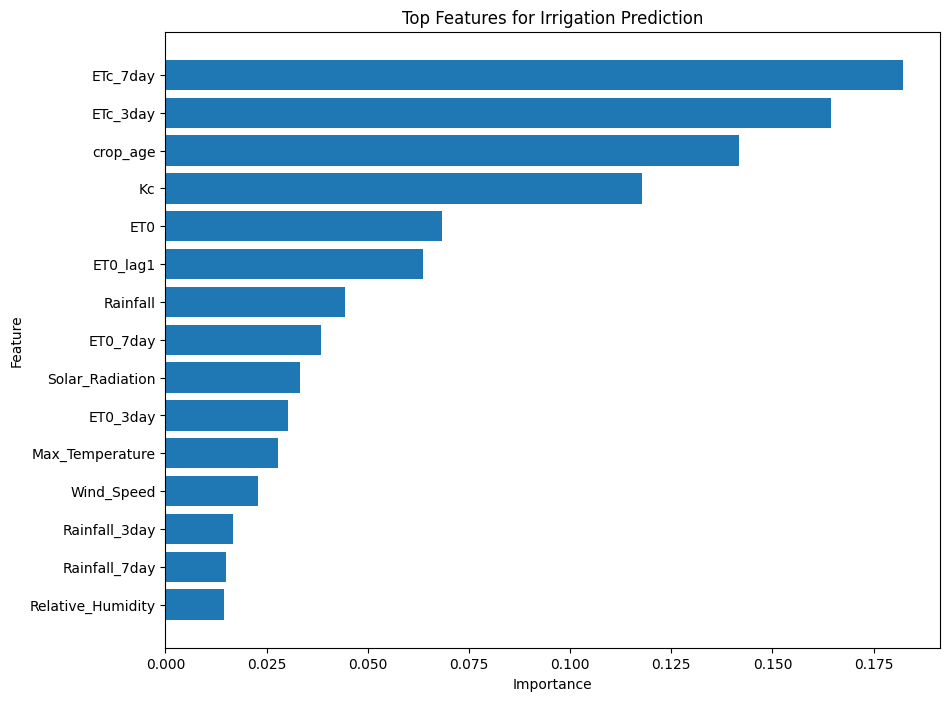

In [170]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"].head(15)[::-1],
    feature_importance["importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features for Irrigation Prediction")

plt.show()

## Regression model

Prepare the regression dataset

In [171]:
# Only use days when irrigation actually occurs
reg_df = weather_df[weather_df["irrigate"] == True].copy()

print("Number of irrigation events:", len(reg_df))
print(reg_df[["Date", "net_irrigation"]].head())

Number of irrigation events: 111
         Date  net_irrigation
28 2016-01-29       38.091335
36 2016-02-06       40.186375
45 2016-02-15       38.427359
52 2016-02-22       39.681171
61 2016-03-02       39.492691


In [172]:
print(reg_df["net_irrigation"].describe())

count    111.000000
mean      38.752124
std        1.655658
min       36.084589
25%       37.618323
50%       38.368160
75%       39.849668
max       43.457838
Name: net_irrigation, dtype: float64


regression features

In [173]:
reg_features = [
    "Tmean",
    "Max_Temperature",
    "Min_Temperature",
    "Relative_Humidity",
    "Rainfall",
    "Wind_Speed",
    "Solar_Radiation",
    "ET0",
    "ET0_lag1",
    "ET0_3day",
    "ET0_7day",
    "Rainfall_3day",
    "Rainfall_7day",
    "crop_age",
    "Kc",
    "field_capacity",
    "wilting_point",
    "root_depth",
    "ETc_3day",
    "ETc_7day"
]

X_reg = reg_df[reg_features]
y_reg = reg_df["net_irrigation"]

In [175]:
print(X_reg.shape)
print(y_reg.shape)

(111, 20)
(111,)


## Train/test split

In [174]:
split_index = int(len(reg_df) * 0.8)

X_train_reg = X_reg.iloc[:split_index]
X_test_reg = X_reg.iloc[split_index:]

y_train_reg = y_reg.iloc[:split_index]
y_test_reg = y_reg.iloc[split_index:]

print("Training samples:", len(X_train_reg))
print("Testing samples:", len(X_test_reg))

Training samples: 88
Testing samples: 23


Train a regression mode

In [176]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=10,
    min_samples_leaf=2
)

reg_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_estimators=300,
                      random_state=42)

In [177]:
y_pred_reg = reg_model.predict(X_test_reg)

evaluate the regression model

In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Performance")
print("----------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Regression Performance
----------------------
MAE : 1.3597299788167185
RMSE: 1.6688730298175711
R²  : 0.1300929018876964


compare actual vs predicted

In [192]:
comparison = pd.DataFrame({
    "Date": reg_df.iloc[split_index:]["Date"].values,
    "Actual": y_test_reg.values,
    "Predicted": y_pred_reg
})

print(comparison.head(20))

         Date     Actual  Predicted
0  2023-03-08  38.758621  39.884228
1  2023-03-13  37.213675  38.402669
2  2023-03-19  41.492534  39.286483
3  2023-03-28  38.959171  37.864932
4  2024-02-01  38.887286  38.049934
5  2024-02-09  39.722430  38.073318
6  2024-02-17  37.445745  38.299686
7  2024-02-26  38.187986  38.091010
8  2024-03-06  38.845010  38.090461
9  2024-03-12  38.341936  38.280122
10 2024-03-18  40.466028  38.745189
11 2024-03-26  37.768236  37.926041
12 2025-01-12  38.926073  38.010433
13 2025-01-22  36.084589  38.578495
14 2025-02-07  39.366118  38.239140
15 2025-02-14  37.491363  38.072306
16 2025-02-21  42.250550  39.191115
17 2025-02-27  37.530805  40.323263
18 2025-03-05  43.360508  39.796223
19 2025-03-13  36.172591  38.032302


In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_reg = rf_regressor.predict(X_test_reg)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Performance")
print("--------------------------------")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.3f}")

Regression Model Performance
--------------------------------
MAE  : 1.36 mm
RMSE : 1.67 mm
R²   : 0.130


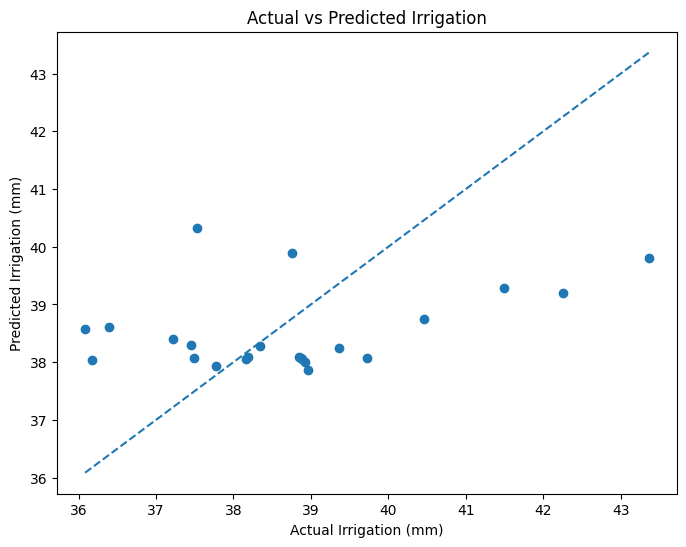

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test_reg, y_pred_reg)

# Perfect prediction line
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Irrigation (mm)")
plt.ylabel("Predicted Irrigation (mm)")
plt.title("Actual vs Predicted Irrigation")

plt.show()

regression 2.0

In [195]:
# Train the regresion model
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

rf_regressor.fit(X_train_reg, y_train_reg)

print("Regression model trained successfully.")

Regression model trained successfully.


In [196]:
# step 2: Generate predictions

y_pred_reg = rf_regressor.predict(X_test_reg)

print("Predictions generated:", len(y_pred_reg))

Predictions generated: 23


In [197]:
# evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Performance")
print("----------------------------")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.3f}")


Regression Model Performance
----------------------------
MAE  : 1.36 mm
RMSE : 1.67 mm
R²   : 0.130


## regression 3.0


In [198]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42
    )
}

In [199]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():

    model.fit(X_train_reg, y_train_reg)

    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    r2 = r2_score(y_test_reg, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

               Model       MAE      RMSE        R2
0      Random Forest  1.359730  1.668873  0.130093
2        Extra Trees  1.405685  1.703550  0.093566
1  Gradient Boosting  1.542595  1.907654 -0.136647


# final regression model

In [200]:
from sklearn.ensemble import ExtraTreesRegressor

final_regressor = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

final_regressor.fit(X_train_reg, y_train_reg)

y_pred_reg = final_regressor.predict(X_test_reg)

In [209]:
joblib.dump(final_regressor, "irrigation_regressor.pkl")

print("Regression model saved.")

Regression model saved.


## save  feature lists

In [210]:
classification_features = X_train.columns.tolist()

joblib.dump(
    classification_features,
    "classification_features.pkl"
)

['classification_features.pkl']

In [211]:
regression_features = X_train_reg.columns.tolist()

joblib.dump(
    regression_features,
    "regression_features.pkl"
)

['regression_features.pkl']

## Create AI Irrigation Advisor

In [212]:
def irrigation_advisor(
    data,
    classifier,
    regressor,
    classification_features,
    regression_features
):
    """
    AI Irrigation Advisor.

    Classification model:
        Determines whether irrigation is required.

    Regression model:
        Estimates irrigation water requirement in mm.
    """

    # Classification prediction
    X_class = data[classification_features]

    irrigation_prediction = classifier.predict(X_class)[0]

    # No irrigation
    if irrigation_prediction == 0:

        return {
            "irrigate": False,
            "recommended_water_mm": 0.0
        }

    # Irrigation required
    X_reg = data[regression_features]

    predicted_water = regressor.predict(X_reg)[0]

    # Prevent negative predictions
    predicted_water = max(0, predicted_water)

    return {
        "irrigate": True,
        "recommended_water_mm": predicted_water
    }

In [213]:
demo_row = weather_df.iloc[[32]].copy()

In [217]:
result = irrigation_advisor(
    data=demo_row,
    classifier=clf_final,
    regressor=final_regressor,
    classification_features=classification_features,
    regression_features=regression_features
)

print(result)

{'irrigate': True, 'recommended_water_mm': np.float64(38.029615982941955)}


presentation

In [218]:
print("=" * 50)
print("       AI IRRIGATION ADVISOR")
print("=" * 50)

print(f"Date: {demo_row['Date'].iloc[0].date()}")

if "growth_stage" in demo_row.columns:
    print(f"Crop stage: {demo_row['growth_stage'].iloc[0]}")

if "crop_age" in demo_row.columns:
    print(f"Crop age: {demo_row['crop_age'].iloc[0]} days")

if "ET0" in demo_row.columns:
    print(f"ET₀: {demo_row['ET0'].iloc[0]:.2f} mm/day")

if "ETc" in demo_row.columns:
    print(f"ETc: {demo_row['ETc'].iloc[0]:.2f} mm/day")

print()

if result["irrigate"]:
    print("🚿 IRRIGATION REQUIRED")
    print(
        f"Recommended irrigation: "
        f"{result['recommended_water_mm']:.2f} mm"
    )
else:
    print("🌧️ NO IRRIGATION REQUIRED")

print("=" * 50)

       AI IRRIGATION ADVISOR
Date: 2016-02-02
Crop stage: Development
Crop age: 32 days
ET₀: 5.99 mm/day
ETc: 5.39 mm/day

🚿 IRRIGATION REQUIRED
Recommended irrigation: 38.03 mm


In [219]:
import os

print(os.getcwd())

/content


In [220]:
os.listdir()

['.config',
 'irrigation_regressor.pkl',
 'regression_features.pkl',
 'drive',
 'irrigation_classifier.pkl',
 'classification_features.pkl',
 'sample_data']

In [221]:
import os

project_path = "/content/drive/MyDrive/Colab Notebooks"

for item in os.listdir(project_path):
    print(item)

Untitled0.ipynb
Untitled1.ipynb
Untitled2 (1).ipynb
Untitled2.ipynb
Untitled3.ipynb
Untitled4.ipynb
Untitled5.ipynb
Untitled6.ipynb
Untitled7.ipynb
Untitled8.ipynb
Untitled9.ipynb
Untitled (2)
Untitled (1)
Untitled11.ipynb
Untitled12.ipynb
Untitled10.ipynb
Untitled13.ipynb
Untitled14.ipynb
Untitled15.ipynb
Untitled16.ipynb
Untitled17.ipynb
N_Proj_weather dataset.ipynb
Untitled19.ipynb
Untitled18.ipynb
Untitled
Untitled20.ipynb
Untitled21.ipynb
Untitled22.ipynb
04_feature_engineering.ipynb
src
03_Test_FAO56.ipynb


In [222]:
data_path = "/content/drive/MyDrive/Colab Notebooks/data"

for root, dirs, files in os.walk(data_path):
    for file in files:
        print(os.path.join(root, file))

In [223]:
weather_df.to_csv("data/processed/irrigation_dataset.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data/processed'

In [224]:
import shutil

destination = "/content/drive/MyDrive/Colab Notebooks/models"

os.makedirs(destination, exist_ok=True)

for file in [
    "irrigation_classifier.pkl",
    "classification_features.pkl",
    "irrigation_regressor.pkl",
    "regression_features.pkl"
]:
    shutil.copy(file, destination)

print("Models saved to Google Drive.")

Models saved to Google Drive.


In [225]:
import joblib
import pandas as pd
import numpy as np

# Load models
classifier = joblib.load("irrigation_classifier.pkl")
regressor = joblib.load("irrigation_regressor.pkl")

# Load the exact features used during training
classification_features = joblib.load("classification_features.pkl")
regression_features = joblib.load("regression_features.pkl")

print("Models loaded successfully.")
print("\nClassification features:")
print(classification_features)

print("\nRegression features:")
print(regression_features)

Models loaded successfully.

Classification features:
['Tmean', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation', 'ET0', 'crop_age', 'Kc', 'field_capacity', 'wilting_point', 'root_depth', 'ET0_lag1', 'ET0_3day', 'ET0_7day', 'Rainfall_3day', 'Rainfall_7day', 'ETc_3day', 'ETc_7day']

Regression features:
['Tmean', 'Max_Temperature', 'Min_Temperature', 'Relative_Humidity', 'Rainfall', 'Wind_Speed', 'Solar_Radiation', 'ET0', 'ET0_lag1', 'ET0_3day', 'ET0_7day', 'Rainfall_3day', 'Rainfall_7day', 'crop_age', 'Kc', 'field_capacity', 'wilting_point', 'root_depth', 'ETc_3day', 'ETc_7day']


In [226]:
def irrigation_advisor(row):

    # -----------------------------
    # 1. CLASSIFICATION
    # -----------------------------

    X_class = pd.DataFrame([row])[classification_features]

    irrigation_needed = classifier.predict(X_class)[0]

    # Probability of irrigation
    irrigation_probability = classifier.predict_proba(X_class)[0][1]


    # -----------------------------
    # 2. REGRESSION
    # -----------------------------

    if irrigation_needed:

        X_reg = pd.DataFrame([row])[regression_features]

        predicted_irrigation = regressor.predict(X_reg)[0]

        # Don't allow negative irrigation
        predicted_irrigation = max(0, predicted_irrigation)

    else:
        predicted_irrigation = 0.0


    return {
        "irrigation_needed": bool(irrigation_needed),
        "irrigation_probability": irrigation_probability,
        "predicted_irrigation_mm": predicted_irrigation
    }

In [227]:
# Select the most recent day
demo_row = weather_df.iloc[-1]

result = irrigation_advisor(demo_row)

print("AI IRRIGATION ADVISOR")
print("=" * 40)

print("Date:", demo_row["Date"])
print("Crop age:", demo_row["crop_age"])
print("Growth stage:", demo_row["growth_stage"])
print("ET0:", round(demo_row["ET0"], 2), "mm/day")
print("ETc:", round(demo_row["ETc"], 2), "mm/day")
print("Rainfall:", round(demo_row["Rainfall"], 2), "mm")

print("\nAI DECISION")
print("-" * 40)

if result["irrigation_needed"]:
    print("Irrigation required: YES")
    print(
        "Probability:",
        round(result["irrigation_probability"] * 100, 1),
        "%"
    )
    print(
        "Recommended irrigation:",
        round(result["predicted_irrigation_mm"], 2),
        "mm"
    )
else:
    print("Irrigation required: NO")
    print(
        "Probability:",
        round(result["irrigation_probability"] * 100, 1),
        "%"
    )
    print("Recommended irrigation: 0 mm")

AI IRRIGATION ADVISOR
Date: 2025-12-31 00:00:00
Crop age: 364
Growth stage: No crop
ET0: 5.35 mm/day
ETc: 0.0 mm/day
Rainfall: 0.3 mm

AI DECISION
----------------------------------------
Irrigation required: NO
Probability: 0.0 %
Recommended irrigation: 0 mm


In [228]:
print("\n" + "=" * 55)
print("        🌱 AI TOMATO IRRIGATION ADVISOR")
print("=" * 55)

print(f"Date              : {demo_row['Date'].date()}")
print(f"Crop stage        : {demo_row['growth_stage']}")
print(f"Crop age          : {demo_row['crop_age']} days")
print(f"ET₀               : {demo_row['ET0']:.2f} mm/day")
print(f"ETc               : {demo_row['ETc']:.2f} mm/day")
print(f"Rainfall          : {demo_row['Rainfall']:.2f} mm")
print(f"Soil depletion    : {demo_row['depletion']:.2f} mm")

print("-" * 55)

if result["irrigation_needed"]:
    print("🚨 IRRIGATION REQUIRED")
    print(
        f"Confidence        : "
        f"{result['irrigation_probability']*100:.1f}%"
    )
    print(
        f"Recommended water : "
        f"{result['predicted_irrigation_mm']:.2f} mm"
    )
else:
    print("✅ NO IRRIGATION REQUIRED")
    print(
        f"Confidence        : "
        f"{(1-result['irrigation_probability'])*100:.1f}%"
    )
    print("Recommended water : 0.00 mm")

print("=" * 55)


        🌱 AI TOMATO IRRIGATION ADVISOR
Date              : 2025-12-31
Crop stage        : No crop
Crop age          : 364 days
ET₀               : 5.35 mm/day
ETc               : 0.00 mm/day
Rainfall          : 0.30 mm
Soil depletion    : 0.00 mm
-------------------------------------------------------
✅ NO IRRIGATION REQUIRED
Confidence        : 100.0%
Recommended water : 0.00 mm
